# 01 — Data Exploration

Explores the cleaned literature dataset produced by `src/module_01_dataset.py`.

Covers:
- Dataset shape, source study count, and coverage of the three endpoints
- Concentration range and distribution
- Missingness map (including imputation flags)
- Compound abundance distributions by structural class
- Crop species / extraction method / solvent breakdown
- Correlation among raw endpoints

**Inputs:** `data/processed/dataset.csv`, `data/processed/dataset_summary.json`,
`data/processed/imputation_flags.csv`

Run Module 1 first if these files don't exist yet:
```bash
python src/module_01_dataset.py
```

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, "../src")
from utils import load_config

PROJECT_ROOT = Path("..")
config = load_config(str(PROJECT_ROOT / "config" / "config.yaml"))

plt.style.use(config["FIGURES"].get("style", "seaborn-v0_8-whitegrid"))
sns.set_palette(config["FIGURES"].get("color_palette", "colorblind"))
DPI = config["FIGURES"].get("dpi", 300)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dataset.csv"
SUMMARY_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_summary.json"
IMPUTATION_PATH = PROJECT_ROOT / "data" / "processed" / "imputation_flags.csv"

assert DATA_PATH.exists(), (
    f"'{DATA_PATH}' not found. Run `python src/module_01_dataset.py` first."
)

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded dataset: 281 rows × 27 columns


,plant_species,plant_part,extraction_solvent,extraction_method,concentration_mg_per_ml,crop_species,crop_variety,germination_percent,root_length_mm,shoot_length_mm,...,compound_hispidulin,compound_quercetin,compound_kaempferol,compound_caffeic_acid,compound_chlorogenic_acid,compound_caryophyllene,compound_alpha_humulene,compound_alpha_pinene,compound_camphene,compound_linalool
0,lantana camara,leaf,aqueous,Petri dish bioassay,0.0000,abelmoschus esculentus,NaN,54.600000,69.378583,91.925225,...,0.926446,0.423967,0.728917,0.464321,0.700255,0.783255,0.699986,0.314451,0.415632,0.610138
1,lantana camara,root,aqueous,aqueous extraction,49.0299,triticum aestivum,NaN,27.308563,22.451571,26.055724,...,0.784353,0.431373,0.867242,0.463071,0.615044,0.786035,0.857352,0.350403,0.376270,0.670421
2,eucalyptus globulus,leaf,aqueous,aqueous extraction,0.0000,triticum aestivum,NaN,58.494384,53.060894,70.254842,...,0.000000,0.000000,0.000000,0.350283,0.938166,0.322939,0.000000,0.860927,0.886146,0.691907
3,ageratina adenophora,leaf,aqueous,aqueous extraction,0.0000,oryza sativa,NaN,53.069704,42.898362,50.448488,...,0.000000,0.529412,0.000000,0.525175,0.000000,0.271093,0.276088,0.000000,0.000000,0.000000
4,lantana camara,leaf,aqueous,aqueous extraction,24.3563,triticum aestivum,NaN,43.631754,40.381259,52.945638,...,0.864259,0.443471,0.908433,0.528510,0.736450,0.847148,0.830845,0.363258,0.339165,0.512933


## 1. Dataset summary

In [2]:
if SUMMARY_PATH.exists():
    with open(SUMMARY_PATH) as f:
        summary = json.load(f)
    for k, v in summary.items():
        print(f"{k:35s}: {v}")
else:
    print("No dataset_summary.json found — showing inline summary instead.")
    print(f"Rows: {len(df)}")
    print(f"Unique studies: {df['study_id'].nunique() if 'study_id' in df else 'N/A'}")

total_rows                         : 281
unique_studies                     : None
unique_donor_species               : 25
concentration_range                : {'min': 0.0, 'max': 105.0987}
germination_percent_coverage       : 1.0
root_length_mm_coverage            : 1.0
shoot_length_mm_coverage           : 1.0


In [3]:
ENDPOINTS = ["germination_percent", "root_length_mm", "shoot_length_mm"]
present_endpoints = [e for e in ENDPOINTS if e in df.columns]

coverage = pd.DataFrame({
    "endpoint": present_endpoints,
    "n_observed": [df[e].notna().sum() for e in present_endpoints],
    "n_missing": [df[e].isna().sum() for e in present_endpoints],
    "pct_observed": [round(100 * df[e].notna().mean(), 1) for e in present_endpoints],
})
coverage

,endpoint,n_observed,n_missing,pct_observed
0,germination_percent,281,0,100.0
1,root_length_mm,281,0,100.0
2,shoot_length_mm,281,0,100.0


## 2. Concentration distribution

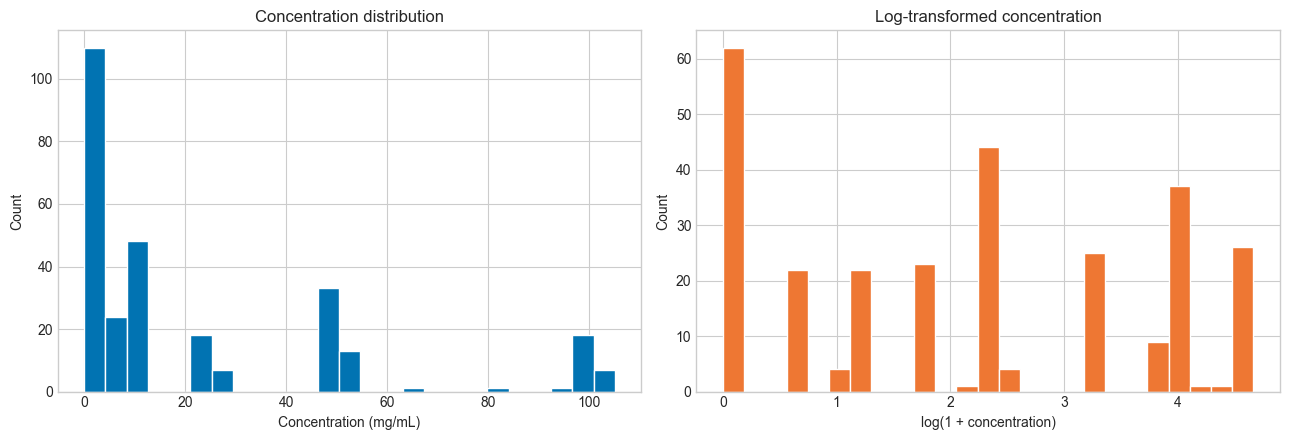

count    281.000000
mean      22.635822
std       30.688845
min        0.000000
25%        0.993300
50%        9.755100
75%       48.758200
max      105.098700
Name: concentration_mg_per_ml, dtype: float64


In [4]:
conc_col = "concentration_mg_per_ml"
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df[conc_col].dropna(), bins=25, edgecolor="white")
axes[0].set_xlabel("Concentration (mg/mL)")
axes[0].set_ylabel("Count")
axes[0].set_title("Concentration distribution")

axes[1].hist(np.log1p(df[conc_col].dropna()), bins=25, edgecolor="white", color="#EE7733")
axes[1].set_xlabel("log(1 + concentration)")
axes[1].set_ylabel("Count")
axes[1].set_title("Log-transformed concentration")

plt.tight_layout()
plt.show()

print(df[conc_col].describe())

## 3. Missingness map

Includes both raw missingness and which values were filled by Module 1's imputation strategy.

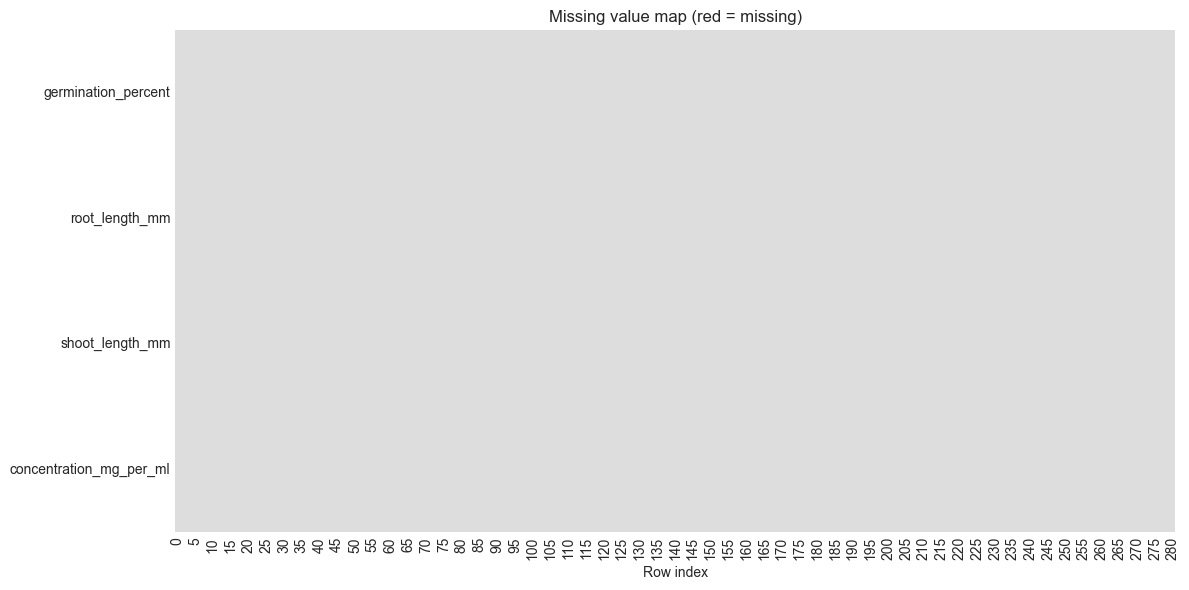

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
missing_matrix = df[present_endpoints + [conc_col]].isna()
sns.heatmap(missing_matrix.T, cbar=False, cmap=["#dddddd", "#cc3311"], ax=ax)
ax.set_title("Missing value map (red = missing)")
ax.set_xlabel("Row index")
plt.tight_layout()
plt.show()

In [6]:
if IMPUTATION_PATH.exists():
    imputation_flags = pd.read_csv(IMPUTATION_PATH, index_col=0)
    imputed_counts = imputation_flags.sum().sort_values(ascending=False)
    imputed_counts = imputed_counts[imputed_counts > 0]
    if len(imputed_counts) > 0:
        fig, ax = plt.subplots(figsize=(10, max(3, 0.3 * len(imputed_counts))))
        imputed_counts.plot(kind="barh", ax=ax, color="#0077BB")
        ax.set_xlabel("Number of imputed values")
        ax.set_title("Imputation summary by column")
        plt.tight_layout()
        plt.show()
    else:
        print("No imputed values recorded.")
else:
    print("No imputation_flags.csv found.")

No imputed values recorded.


## 4. Compound abundance distributions by structural class

In [7]:
compound_cols = [c for c in df.columns if c.startswith("compound_")]
print(f"Found {len(compound_cols)} compound columns:")
print(compound_cols)

TERPENOIDS = [c for c in compound_cols if any(
    k in c for k in ["lantadene", "icterogenin", "caryophyllene", "humulene", "pinene", "camphene", "linalool"]
)]
FLAVONOIDS = [c for c in compound_cols if any(k in c for k in ["luteolin", "hispidulin", "quercetin", "kaempferol"])]
PHENOLICS = [c for c in compound_cols if any(k in c for k in ["caffeic", "chlorogenic"])]

class_map = {**{c: "terpenoid" for c in TERPENOIDS},
             **{c: "flavonoid" for c in FLAVONOIDS},
             **{c: "phenolic" for c in PHENOLICS}}

Found 16 compound columns:
['compound_lantadene_a', 'compound_lantadene_b', 'compound_lantadene_c', 'compound_lantadene_d', 'compound_icterogenin', 'compound_luteolin', 'compound_hispidulin', 'compound_quercetin', 'compound_kaempferol', 'compound_caffeic_acid', 'compound_chlorogenic_acid', 'compound_caryophyllene', 'compound_alpha_humulene', 'compound_alpha_pinene', 'compound_camphene', 'compound_linalool']


C:\Users\rudsi\AppData\Local\Temp\ipykernel_125232\2997387933.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


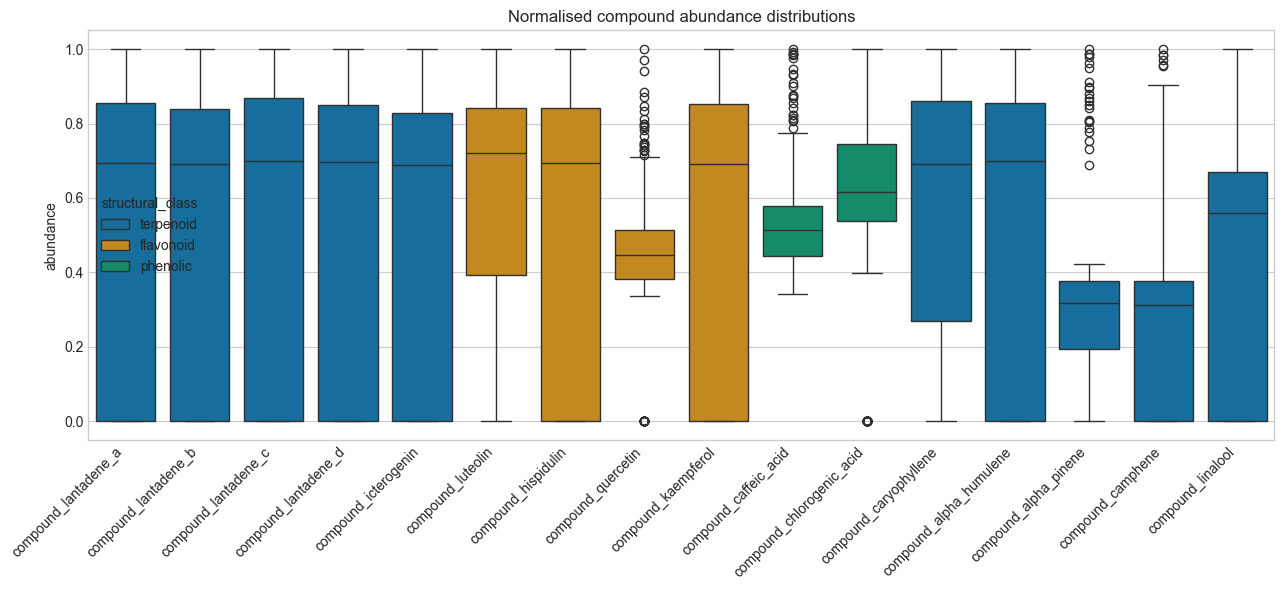

In [8]:
if compound_cols:
    melted = df[compound_cols].melt(var_name="compound", value_name="abundance").dropna()
    melted["structural_class"] = melted["compound"].map(class_map).fillna("other")

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.boxplot(data=melted, x="compound", y="abundance", hue="structural_class",
                dodge=False, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_title("Normalised compound abundance distributions")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()
else:
    print("No compound columns present in the dataset.")

## 5. Correlation among raw endpoints

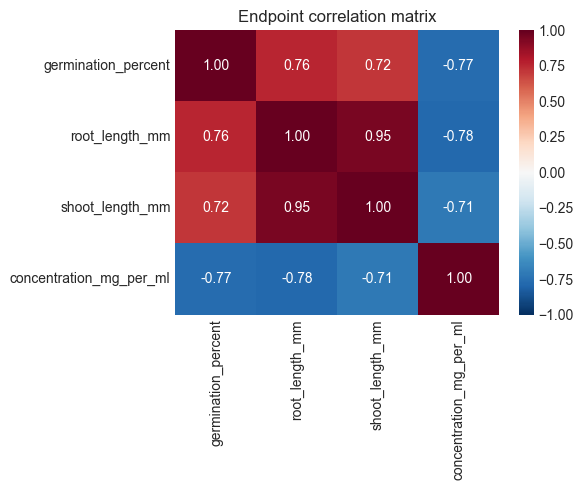

In [9]:
if len(present_endpoints) >= 2:
    corr = df[present_endpoints + [conc_col]].corr()
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title("Endpoint correlation matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Fewer than two endpoints present; skipping correlation matrix.")

## 6. Notes for next stage

Use this notebook to sanity-check the literature dataset before feature
engineering. Things worth flagging here:

- Studies with unusually high imputation rates (consider excluding or
  re-checking source papers)
- Concentration ranges that don't overlap with the planned wet-lab
  concentrations (`LOCK.experimental_concentrations` in `config.yaml`)
- Compound columns that are mostly zero/NaN — these will rely heavily on
  class-mean imputation downstream

Proceed to `02_feature_engineering_exploration.ipynb` once the dataset looks clean.